<a href="https://colab.research.google.com/github/bnjmnaddo-afk/Data/blob/main/AISExerciseCorrection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hi Class,

I hope you're all enjoying the weekend. For those who want to keep practicing their Python and Pandas and prepare for the capstone assignment, here is an additional exercise, working with a Time Series.

Let's explore the maritime world. In this dataset: https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst, you'll be able to visualize all the positions of ships off US coasts for one day: 01/08/2025. You can look this URL up directly in pandas, it can handle the decompression (this is a compressed CSV). This is a large dataset, so your operations may take longer than what we've seen so far. To understand what each column is, here is the data dictionary: https://coast.noaa.gov/data/marinecadastre/ais/data-dictionary.pdf

Please provide a notebook (.ipynb file) posted here and on your Github, in your data-analytics repo (please add a link to the repo in your submission) with the following:
- Load the dataframe
- Set the index to the base_date_time. Your index should be a DateTimeIndex
- Clean the data: we don't want any row where the sog is null

First Analysis: When are boats out? Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?

Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day. To get to this, you must:

 a) Figure out when the boat was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)

 b) Create a duration column, which is the difference between each "base_date_time"

 c) Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.

 d) Sum up the "duration" column to see how long the engines were active for that day. This will allow us to answer the boat captain

Bonus: create a function that takes the MMSI as a parameter, and return the active engine time for that day. Name this function calculate_total_active_engine_time.

This is a hard exercise. I recommend getting through the first analysis, with clean data and a well defined index. The second analysis is hard, but I hope I've guided you enough. I highly recommend working in groups for this analysis. Good luck!

# Load and clean the data

In [ ]:
URL = " https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"

In [ ]:
import pandas as pd
df = pd.read_csv(URL)

In [ ]:
df

,mmsi,base_date_time,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver,hour
base_date_time,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00+00:00,367793030,2025-01-08 00:00:00+00:00,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B,0
2025-01-08 00:00:00+00:00,338160209,2025-01-08 00:00:00+00:00,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B,0
2025-01-08 00:00:01+00:00,266283000,2025-01-08 00:00:01+00:00,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A,0
2025-01-08 00:00:10+00:00,368013620,2025-01-08 00:00:10+00:00,-74.04712,40.10181,0.0,252.3,NaN,MARKET PRICE,NaN,WDJ8153,30.0,NaN,17.0,6.0,NaN,NaN,B,0
2025-01-08 00:00:09+00:00,368144150,2025-01-08 00:00:09+00:00,-119.22453,34.16235,0.0,169.6,NaN,SILENT LADY,NaN,WDL5759,37.0,NaN,12.0,5.0,NaN,NaN,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-08 18:58:42+00:00,368920000,2025-01-08 18:58:42+00:00,144.66472,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A,18
2025-01-08 19:49:42+00:00,368920000,2025-01-08 19:49:42+00:00,144.66471,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A,19
2025-01-08 21:13:42+00:00,368920000,2025-01-08 21:13:42+00:00,144.66474,13.42225,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A,21


In [ ]:
# Let's set the index
df["base_date_time"] = pd.to_datetime(df["base_date_time"], utc=True)
df = df.set_index(df["base_date_time"])

In [ ]:
# Let's drop the rows where SoG is null
df = df.dropna(subset=["sog"])

# First analysis

In [ ]:
def extract_hour(row: pd.Series) -> int:
  base_date_time = row["base_date_time"]
  return base_date_time.hour

df["hour"] = df.apply(extract_hour, axis=1)

/tmp/ipykernel_3100/544543377.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hour"] = df.apply(extract_hour, axis=1)


<Axes: xlabel='hour'>

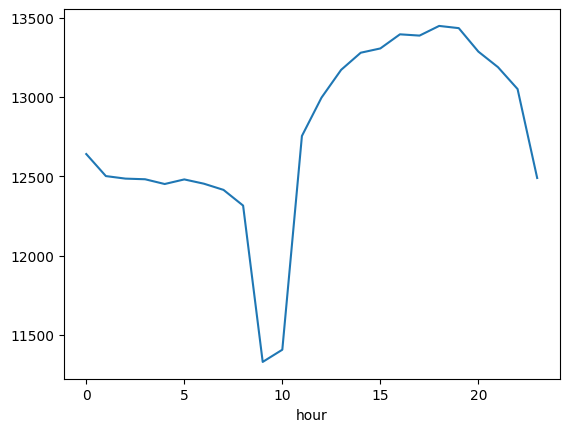

In [ ]:
df.groupby(["hour"])["mmsi"].nunique().plot(kind="line")

# Second analysis

In [ ]:
# Let's extract the dataframe for the Henry Hudson
hh = df[df["mmsi"] == 366651000]

In [ ]:
# Let's create the "acceleration" column

# First, sort the dataframe by time
hh = hh.sort_index()

# Let's caclulate the difference in speed between each row
hh["acceleration"] = hh["sog"].diff()

In [ ]:
# Let's calculate the "duration" column
hh["duration"] = hh["base_date_time"].diff()

In [ ]:
# We only the rows where the acceleration is positive
hh = hh[hh['acceleration'] > 0]

In [ ]:
hh["duration"].sum()

Timedelta('0 days 08:03:24')

# Bonus

In [ ]:
def calculate_total_active_engine_time(mmsi: int):
  boat_df = df[df["mmsi"] == mmsi]
  boat_df = boat_df.sort_index()

  # Let's caclulate the difference in speed between each row
  boat_df["acceleration"] = boat_df["sog"].diff()
  boat_df["duration"] = boat_df["base_date_time"].diff()
  boat_df = boat_df[boat_df['acceleration'] > 0]
  return boat_df["duration"].sum()

In [ ]:
calculate_total_active_engine_time(366629680)

Timedelta('0 days 05:53:03')